# Neural ODEs, part 2 — a larger Case 1 library and symbolic regression

This notebook extends [`node_case_studies.ipynb`](node_case_studies.ipynb) in four ways:

1. **A larger Case 1 library.** Case 1 grows from 4 to 11 candidate mechanisms: the four original rate
   laws, each also with first-order cell death ($k_d$), plus Tessier, Moser and Aiba.
2. **A run from a law that is *not* in the library** (the "hidden" run), to see what the pipeline does
   when the right answer isn't among the candidates.
3. **Symbolic regression** on the rates the Neural ODE learned. It proposes new rate laws, including
   ones outside the library, and they are then tested against the data in the same way as the library.
4. **Symbolic regression for Case 2** (xylitol), on the two learned rates μ1 and μ2 of the two virtual
   fermentations from part 1.

The Neural ODE, the refinement and the BIC selection are the same as in part 1 (see `node/README.md`),
with one addition: the Neural ODE now also learns a death rate $k_d$.

**Requirements:** kintrace's `requirements.txt` plus `torchdiffeq` and `sympy`.
Run from `kintrace/node/notebooks/`. The full notebook takes about 15 min on a CPU.

In [1]:
import os, sys, copy, time, itertools, warnings, contextlib
import numpy as np
import pandas as pd
import sympy as sp
import torch
import torch.nn as nn
from torchdiffeq import odeint
from scipy.integrate import odeint as scipy_odeint, ODEintWarning
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))   # kintrace repository root
assert os.path.isdir(os.path.join(ROOT, "kinetic_models")), "run this notebook from kintrace/node/notebooks"
sys.path.insert(0, ROOT)

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)            # the networks are tiny: extra threads only add overhead
warnings.filterwarnings("ignore", category=ODEintWarning)     # odeint warns on stiff candidates during fitting


@contextlib.contextmanager
def fortran_quiet():
    """LSODA (inside odeint) prints its warnings from Fortran, straight to the process's stdout, so
    Python cannot filter them. Point file descriptor 1 at /dev/null while it runs."""
    saved, null = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 1)
    try:
        yield
    finally:
        os.dup2(saved, 1)
        os.close(null)
        os.close(saved)

C_NODE, C_MECH, C_SR, C_DATA, C_TRUE = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 1.8,
})

## Shared building blocks (unchanged from part 1)

* `HybridODE` / `train_node`: the Neural ODE, integrated with RK4 and trained with a growing horizon
  and a trainable correction to the initial state. *Changed from part 1:* the initial state starts from
  the median of the first three samples instead of the first sample alone. With 3 % noise and clipping at
  zero, the first biomass sample can read 0 g/L, and a culture started at zero never grows. The loss now
  weights each channel by its *range* rather than its maximum, matching the noise model (3 % of range).
  For a run whose substrate never falls near zero, the maximum over-states the noise.
* `refine`: bounded least squares in normalised coordinates z ∈ [1, 2], with a finite-difference step of 1e-3.
* `identify`: refines every candidate from each starting point, keeps the best fit, and ranks the candidates
  by BIC = χ² + k·ln n. The initial state is refined together with the parameters.

In [2]:
def mlp(n_in, n_out, hidden=16):
    return nn.Sequential(nn.Linear(n_in, hidden), nn.Tanh(),
                         nn.Linear(hidden, hidden), nn.Tanh(),
                         nn.Linear(hidden, n_out))


class HybridODE(nn.Module):
    """Known mass balances with neural-network kinetics. Subclasses implement forward(t, y) -> dy/dt.
    The measured channels come first in the state; the volume V (known from the feed) comes last."""
    step = 0.5                                                   # RK4 step [h]

    def __init__(self, Y_obs, V0, n_start=3):
        super().__init__()
        self.scale = torch.tensor(np.nanmax(Y_obs, 0))           # per-channel scale of the NN inputs
        self.loss_scale = torch.tensor(np.nanmax(Y_obs, 0) - np.nanmin(Y_obs, 0))   # range: weights of the loss
        self.y_first = torch.nan_to_num(torch.tensor(np.nanmedian(Y_obs[:n_start], 0)))   # robust start
        self.dy0 = nn.Parameter(torch.zeros(Y_obs.shape[1]))     # correction to the first sample
        self.V0 = V0

    def simulate(self, t):
        x0 = (self.y_first + 0.05 * self.scale * self.dy0).clamp(min=0)
        y0 = torch.cat([x0, torch.tensor([self.V0])])
        return odeint(self, y0, torch.as_tensor(t), method="rk4", options=dict(step_size=self.step))


def train_node(model, t_obs, Y_obs, n_iter=300, lr=5e-3):
    """Adam on the range-scaled MSE; NaNs in Y_obs (missing samples) are ignored.
    Keeps the best full-horizon state and returns its loss."""
    t, Y = torch.tensor(t_obs), torch.tensor(Y_obs)
    mask, Y = torch.isfinite(Y), torch.nan_to_num(Y)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss, best_state = np.inf, None
    for it in range(n_iter):
        k = max(4, int(min(1.0, 0.25 + it / (0.5 * n_iter)) * len(t)))     # growing horizon
        opt.zero_grad()
        r = (model.simulate(t[:k])[:, :Y.shape[1]] - Y[:k]) / model.loss_scale
        loss = (r[mask[:k]] ** 2).mean()
        loss.backward()
        opt.step()
        if k == len(t) and loss.item() < best_loss:
            best_loss, best_state = loss.item(), copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return best_loss


def refine(simulate, theta0, lb, ub, t_obs, Y_obs, sigma):
    """Bounded least squares in normalised coordinates z in [1, 2]. Returns (theta, chi2, n_evals)."""
    mask = np.isfinite(Y_obs)
    to_theta = lambda z: lb + (z - 1) * (ub - lb)

    def residuals(z):
        Y = simulate(to_theta(z), t_obs)
        return np.full(mask.sum(), 1e3) if Y is None else ((Y - Y_obs) / sigma)[mask]

    z0 = 1 + (np.clip(theta0, lb, ub) - lb) / (ub - lb)
    r = least_squares(residuals, z0, bounds=(1, 2), diff_step=1e-3, max_nfev=300)
    return to_theta(r.x), float(np.sum(r.fun ** 2)), r.nfev


def identify(candidates, starts, simulate, bounds, x0, t_obs, Y_obs, sigma):
    """Refine every candidate from each starting point in starts(mid) (a dict name -> theta0), keep the best
    fit, and rank the candidates by BIC."""
    x0 = np.asarray(x0, dtype=float)
    x0_lb, x0_ub = 0.5 * x0, 1.5 * x0 + 0.05 * np.nanmax(Y_obs, 0)
    rows = []
    for mid in candidates:
        (lb, ub), row, best = bounds(mid), dict(mechanism=mid, nfev=0), None
        for name, theta0 in starts(mid).items():
            n = len(theta0)
            theta, chi2, nfev = refine(lambda th, t: simulate(mid, th[:n], t, th[n:]), np.r_[theta0, x0],
                                       np.r_[lb, x0_lb], np.r_[ub, x0_ub], t_obs, Y_obs, sigma)
            row[f"chi2 from {name}"], row["nfev"] = chi2, row["nfev"] + nfev
            if best is None or chi2 < best[1]:
                best = (theta, chi2)
        rows.append(dict(row, k=n, chi2=best[1], theta=best[0][:n], x0=best[0][n:]))
    return add_bic(pd.DataFrame(rows).set_index("mechanism"), np.isfinite(Y_obs).sum())


def add_bic(df, n_data):
    """BIC = chi2 + k ln n, and BIC weights exp(-dBIC/2) normalised over the candidates in df."""
    df = df.copy()
    df["BIC"] = df.chi2 + df.k * np.log(n_data)
    w = np.exp(-(df.BIC - df.BIC.min()) / 2)
    df["weight"] = w / w.sum()
    return df

---
## The 11-mechanism library

The mass balance is the same as in part 1, now with an optional death term:

$$\frac{dX}{dt} = (\mu - k_d - D)\,X,\qquad \frac{dS}{dt} = -\frac{\mu X}{Y_{XS}} + D\,(S_{in}-S),\qquad \frac{dV}{dt}=F.$$

| rate law | $\mu(X, S)$ | in the library |
|---|---|---|
| Monod | $\mu_{max}\,\frac{S}{K_S+S}$ | with and without $k_d$ |
| Contois | $\mu_{max}\,\frac{S}{K_cX+S}$ | with and without $k_d$ |
| Haldane | $\mu_{max}\,\frac{S}{K_S+S+S^2/K_I}$ | with and without $k_d$ |
| biomass inhibition | $\mu_{max}\,\frac{S}{K_S+S}\left(1-\frac{X}{X_{max}}\right)$ | with and without $k_d$ |
| Tessier | $\mu_{max}\left(1-e^{-S/K_S}\right)$ | without $k_d$ |
| Moser | $\mu_{max}\,\frac{S^n}{K_S+S^n}$ | without $k_d$ |
| Aiba | $\mu_{max}\,\frac{S}{K_S+S}\,e^{-S/K_I}$ | without $k_d$ |

The parameter ranges are kintrace's (`datagen/param_ranges_simple.py`), extended with
$k_d \in [0.005, 0.1]$ h⁻¹ (the Case 2 range), $n \in [1, 3]$, Moser $K_S \in [0.1, 25]$ and Aiba
$K_I \in [5, 50]$ g/L. As in part 1, fitting uses bounds of 0.1×–5× these ranges.

In [3]:
from datagen.param_ranges_simple import PARAM_RANGES_SIMPLE
from datagen.feed_profiles_simple import make_feed_fn
from datagen.noise import add_gaussian_noise

LAWS = {   # name: (mu(X, S, p), kinetic parameter names)
    "monod":       (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S), ["mumax", "Ks"]),
    "contois":     (lambda X, S, p: p["mumax"] * S / (p["Kc"] * X + S), ["mumax", "Kc"]),
    "haldane":     (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S + S ** 2 / p["KI"]), ["mumax", "Ks", "KI"]),
    "biomass_inh": (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S) * np.maximum(1 - X / p["Xmax"], 0),
                    ["mumax", "Ks", "Xmax"]),
    "tessier":     (lambda X, S, p: p["mumax"] * (1 - np.exp(-S / p["Ks"])), ["mumax", "Ks"]),
    "moser":       (lambda X, S, p: p["mumax"] * S ** p["n"] / (p["Ks"] + S ** p["n"]), ["mumax", "Ks", "n"]),
    "aiba":        (lambda X, S, p: p["mumax"] * S / (p["Ks"] + S) * np.exp(-S / p["KI"]), ["mumax", "Ks", "KI"]),
}
MECHS = {}                                      # mechanism name: (rate law, has death term)
for law in ["monod", "contois", "haldane", "biomass_inh"]:
    MECHS[law], MECHS[law + "+kd"] = (law, False), (law, True)
for law in ["tessier", "moser", "aiba"]:
    MECHS[law] = (law, False)

RANGES = {**PARAM_RANGES_SIMPLE[3], **PARAM_RANGES_SIMPLE[2], **PARAM_RANGES_SIMPLE[4],
          "kd": (0.005, 0.1), "n": (1.0, 3.0)}
RANGES_BY_LAW = {"moser": {"Ks": (0.1, 25.0)}, "aiba": {"KI": (5.0, 50.0)}}


def param_names(mech):
    law, death = MECHS[mech]
    return LAWS[law][1] + (["kd"] if death else []) + ["Yxs"]


def sampling_ranges(mech):
    r = {**RANGES, **RANGES_BY_LAW.get(MECHS[mech][0], {})}
    lo, hi = zip(*[r[name] for name in param_names(mech)])
    return np.array(lo), np.array(hi)


def wide_bounds(mech):
    lo, hi = sampling_ranges(mech)
    return 0.1 * lo, 5 * hi


def rhs(y, t, mu_fn, p, feed, Sin):
    X, S, V = max(y[0], 0.0), max(y[1], 0.0), y[2]
    F = feed(t)
    D = F / V
    mu = mu_fn(X, S, p)
    return [(mu - p.get("kd", 0.0) - D) * X, -mu * X / p["Yxs"] + D * (Sin - S), F]


def simulate_mech(mu_fn, p, t, x0):
    """Integrate the mass balance for any rate law mu_fn(X, S, p); returns [X, S] or None if it fails."""
    try:
        with fortran_quiet():
            y = scipy_odeint(rhs, [*x0, COND["V0"]], t, args=(mu_fn, p, feed, COND["Sin"]),
                             rtol=1e-6, atol=1e-8, mxstep=5000)
    except Exception:
        return None
    return y[:, :2] if np.all(np.isfinite(y)) and np.abs(y).max() < 1e6 else None      # blow-up = failure


def simulate(mech, theta, t, x0):
    return simulate_mech(LAWS[MECHS[mech][0]][0], dict(zip(param_names(mech), theta)), t, x0)


pd.DataFrame({m: {"rate law": law, "death": death, "parameters": ", ".join(param_names(m))}
              for m, (law, death) in MECHS.items()}).T

,rate law,death,parameters
monod,monod,False,"mumax, Ks, Yxs"
monod+kd,monod,True,"mumax, Ks, kd, Yxs"
contois,contois,False,"mumax, Kc, Yxs"
contois+kd,contois,True,"mumax, Kc, kd, Yxs"
haldane,haldane,False,"mumax, Ks, KI, Yxs"
haldane+kd,haldane,True,"mumax, Ks, KI, kd, Yxs"
biomass_inh,biomass_inh,False,"mumax, Ks, Xmax, Yxs"
biomass_inh+kd,biomass_inh,True,"mumax, Ks, Xmax, kd, Yxs"
tessier,tessier,False,"mumax, Ks, Yxs"
moser,moser,False,"mumax, Ks, n, Yxs"


## Data: 11 library runs and one hidden-law run

All runs use the part-1 design: $X_0 = 1$, $S_0 = 30$ g/L, $V_0 = 1.5$ L, $S_{in} = 120$ g/L, 24 h, and a
feed of 0, 0.02, 0.05 and 0.08 L/h in four 6 h segments. Each run has 49 samples of $X$ and $S$ with 3 %
noise. The true parameters lie inside the sampling ranges, with $k_d = 0.04$ h⁻¹ for the death variants.

The **hidden** run combines Haldane inhibition and biomass inhibition:

$$\mu = \mu_{max}\,\frac{S}{K_S+S+S^2/K_I}\left(1-\frac{X}{X_{max}}\right),$$

with $\mu_{max}=0.6$, $K_S=1$, $K_I=20$ g/L and $X_{max}=30$ g/L. Each ingredient is in the library,
but their combination is not.

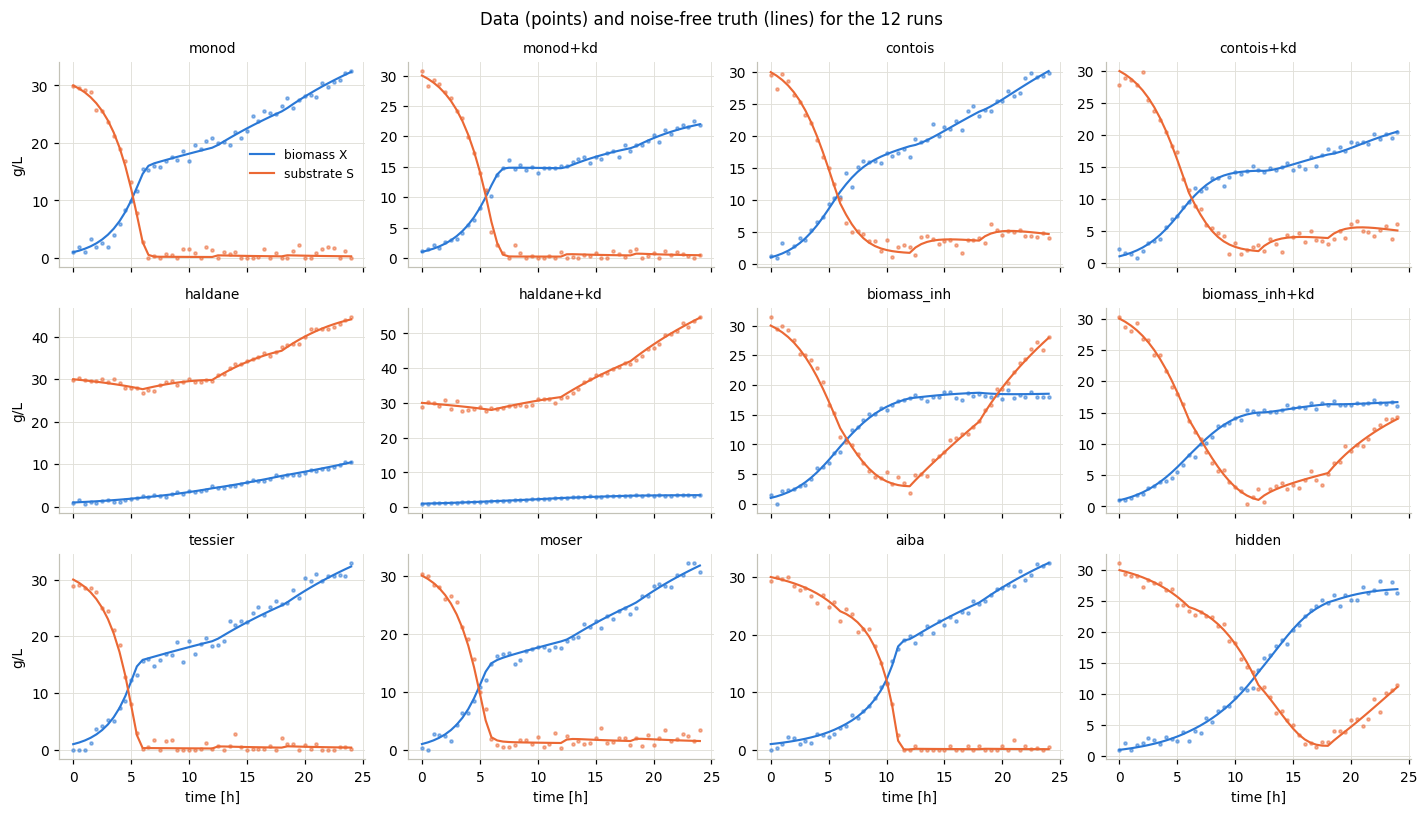

In [4]:
COND = dict(X0=1.0, S0=30.0, V0=1.5, Sin=120.0, t_total=24.0, feed_rates=[0.0, 0.02, 0.05, 0.08])
feed = make_feed_fn(COND)
N_OBS, NOISE = 49, 0.03
TRUE = {   # parameters in param_names order: kinetic, (kd), Yxs
    "monod": [0.5, 2.0, 0.5],             "monod+kd": [0.5, 2.0, 0.04, 0.5],
    "contois": [0.5, 1.0, 0.5],           "contois+kd": [0.5, 1.0, 0.04, 0.5],
    "haldane": [0.6, 1.0, 8.0, 0.5],      "haldane+kd": [0.6, 1.0, 8.0, 0.04, 0.5],
    "biomass_inh": [0.5, 1.0, 20.0, 0.5], "biomass_inh+kd": [0.5, 1.0, 20.0, 0.04, 0.5],
    "tessier": [0.5, 3.0, 0.5],           "moser": [0.5, 16.0, 2.0, 0.5],        "aiba": [0.6, 1.0, 30.0, 0.5],
}
HIDDEN_P = dict(mumax=0.6, Ks=1.0, KI=20.0, Xmax=30.0, Yxs=0.5)
hidden_mu = lambda X, S, p: LAWS["haldane"][0](X, S, p) * np.maximum(1 - X / p["Xmax"], 0)

t_obs = np.linspace(0, COND["t_total"], N_OBS)
x0_true = [COND["X0"], COND["S0"]]
runs = {}                                                     # run name -> true rate function, params, data
for i, (m, theta) in enumerate(TRUE.items()):
    runs[m] = dict(mu_fn=LAWS[MECHS[m][0]][0], p=dict(zip(param_names(m), theta)))
runs["hidden"] = dict(mu_fn=hidden_mu, p=HIDDEN_P)
for i, r in enumerate(runs.values()):
    r["truth"] = simulate_mech(r["mu_fn"], r["p"], t_obs, x0_true)
    r["Y"] = add_gaussian_noise(r["truth"], NOISE, clip_zero=True, seed=i)
    r["sigma"] = NOISE * (r["Y"].max(0) - r["Y"].min(0))      # assumed known measurement noise

fig, axes = plt.subplots(3, 4, figsize=(13, 7.5), sharex=True)
for ax, (name, r) in zip(axes.flat, runs.items()):
    for j, (label, color) in enumerate([("biomass X", "#2a78d6"), ("substrate S", "#eb6834")]):
        ax.plot(t_obs, r["Y"][:, j], "o", color=color, ms=2, alpha=0.5)
        ax.plot(t_obs, r["truth"][:, j], color=color, lw=1.4, label=label)
    ax.set_title(name)
for ax in axes[-1]:
    ax.set_xlabel("time [h]")
for ax in axes[:, 0]:
    ax.set_ylabel("g/L")
axes[0, 0].legend()
fig.suptitle("Data (points) and noise-free truth (lines) for the 12 runs")
fig.tight_layout()

Several laws look alike in this experiment. Monod and Tessier differ only at low $S$, which the fed
phase visits just below the noise level. Adding death mostly lowers the biomass reached. We should expect
the same kind of near-ties as in the paper.

---
## Step 1 — hybrid Neural ODE, now with a death rate

The model is part 1's, plus a trainable $k_d \ge 0$:

$$\mu = \mathrm{softplus}\big(\mathrm{NN}_\phi(X/s_X, S/s_S)\big)\cdot\frac{S}{S+0.1\,s_S},\qquad
\dot X = (\mu - k_d - D)X,\qquad \dot S = -\frac{\mu X}{Y_{XS}} + D(S_{in} - S).$$

In [5]:
class HybridSimple(HybridODE):
    def __init__(self, Y_obs, V0):
        super().__init__(Y_obs, V0)
        self.net = mlp(2, 1)
        self.log_Yxs = nn.Parameter(torch.tensor(np.log(0.5)))
        self.log_kd = nn.Parameter(torch.tensor(np.log(0.01)))

    def mu(self, X, S):
        S = S.clamp(min=0)
        g = nn.functional.softplus(self.net(torch.stack([X, S], -1) / self.scale)).squeeze(-1)
        return g * S / (S + 0.1 * self.scale[1])

    def forward(self, t, y):
        X, S, V = y.unbind(-1)
        F = feed(float(t))
        D = F / V
        mu = self.mu(X, S)
        return torch.stack([(mu - torch.exp(self.log_kd) - D) * X,
                            -mu * X / torch.exp(self.log_Yxs) + D * (COND["Sin"] - S),
                            torch.full_like(V, F)])


T_DENSE = np.linspace(0, COND["t_total"], 97)
for name, r in runs.items():
    t0 = time.time()
    torch.manual_seed(0)
    r["node"] = model = HybridSimple(r["Y"], COND["V0"])
    loss = train_node(model, t_obs, r["Y"], lr=1e-2)
    with torch.no_grad():
        yd = model.simulate(T_DENSE)
        r["dense"] = dict(X=yd[:, 0].numpy(), S=np.clip(yd[:, 1].numpy(), 0, None),
                          mu=model.mu(yd[:, 0], yd[:, 1]).numpy(),
                          Yxs=torch.exp(model.log_Yxs).item(), kd=torch.exp(model.log_kd).item())
        r["x0"] = [r["dense"]["X"][0], r["dense"]["S"][0]]
        r["chi2_node"] = float(np.sum(((model.simulate(t_obs)[:, :2].numpy() - r["Y"]) / r["sigma"]) ** 2))
    print(f"{name:15s} loss {loss:.1e}  Yxs {r['dense']['Yxs']:.3f} (true {r['p']['Yxs']})  "
          f"kd {r['dense']['kd']:.3f} (true {r['p'].get('kd', 0.0)})  [{time.time() - t0:.0f} s]")

monod           loss 7.2e-04  Yxs 0.533 (true 0.5)  kd 0.006 (true 0.0)  [23 s]


monod+kd        loss 5.2e-04  Yxs 0.462 (true 0.5)  kd 0.032 (true 0.04)  [22 s]


contois         loss 9.8e-04  Yxs 0.534 (true 0.5)  kd 0.008 (true 0.0)  [20 s]


contois+kd      loss 1.4e-03  Yxs 0.461 (true 0.5)  kd 0.032 (true 0.04)  [21 s]


haldane         loss 7.9e-04  Yxs 0.547 (true 0.5)  kd 0.011 (true 0.0)  [21 s]


...

biomass_inh+kd  loss 5.9e-04  Yxs 0.466 (true 0.5)  kd 0.031 (true 0.04)  [21 s]


tessier         loss 9.0e-04  Yxs 0.567 (true 0.5)  kd 0.008 (true 0.0)  [22 s]


moser           loss 9.3e-04  Yxs 0.532 (true 0.5)  kd 0.006 (true 0.0)  [21 s]


aiba            loss 5.2e-04  Yxs 0.551 (true 0.5)  kd 0.011 (true 0.0)  [22 s]


hidden          loss 1.5e-03  Yxs 0.567 (true 0.5)  kd 0.016 (true 0.0)  [21 s]


Learned μ(t) against the true μ(t) for every run. The pipeline never sees the true curve; for the hidden
run it is shown only for reference.

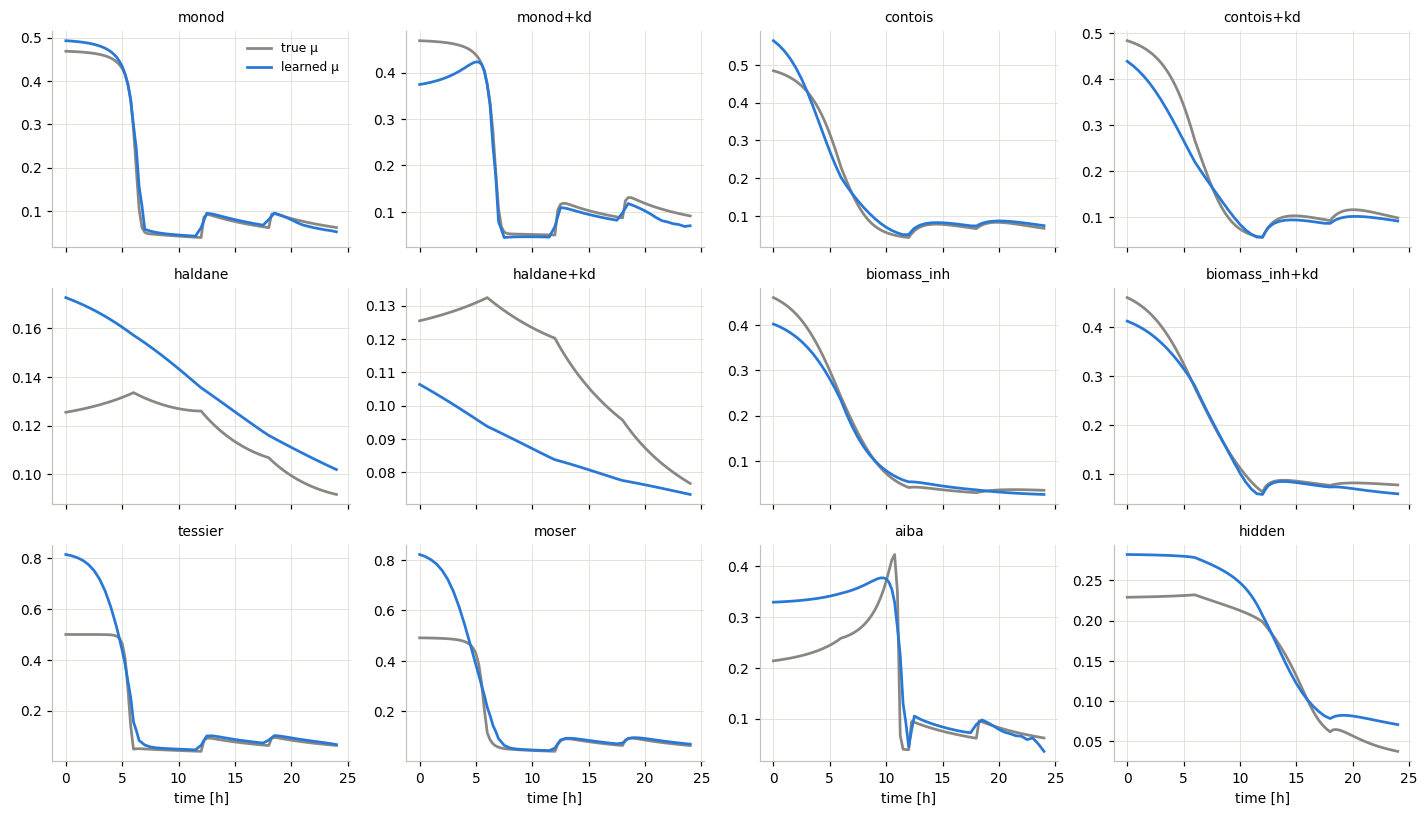

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5), sharex=True)
for ax, (name, r) in zip(axes.flat, runs.items()):
    truth_d = simulate_mech(r["mu_fn"], r["p"], T_DENSE, x0_true)
    ax.plot(T_DENSE, r["mu_fn"](truth_d[:, 0], truth_d[:, 1], r["p"]), color=C_TRUE, label="true μ")
    ax.plot(T_DENSE, r["dense"]["mu"], color=C_NODE, label="learned μ")
    ax.set_title(name)
for ax in axes[-1]:
    ax.set_xlabel("time [h]")
axes[0, 0].legend()
fig.tight_layout()

## Steps 2–4 — match, refine and select over the 11 mechanisms

This is the part-1 procedure. Each candidate is refined from the rate law matched to the learned μ and
from the centre of its sampling ranges, and the better fit is scored with BIC. For death variants, $k_d$
starts at the Neural ODE's value.

The table also shows the Neural ODE's own χ². It is trained with a few hundred Adam steps, so it usually
fits a little *worse* than a refined mechanism. It is only a rough reference here.

In [7]:
def match(mech, dense):
    """Initial guess: fit the candidate's rate law to the learned mu; Yxs and kd come from the Neural ODE."""
    law, death = MECHS[mech]
    mu_fn, kin = LAWS[law]
    lb, ub = wide_bounds(mech)
    lo, hi = sampling_ranges(mech)
    k = len(kin)

    def residuals(theta_kin):
        return mu_fn(dense["X"], dense["S"], dict(zip(kin, theta_kin))) - dense["mu"]

    r = least_squares(residuals, 0.5 * (lo + hi)[:k], bounds=(lb[:k], ub[:k]), x_scale=(ub - lb)[:k])
    theta = np.r_[r.x, [dense["kd"]] if death else [], dense["Yxs"]]
    return np.clip(theta, lb, ub)


N_DATA = 2 * N_OBS
for name, r in runs.items():
    t0 = time.time()
    r["sel"] = identify(list(MECHS),
                        starts=lambda m: {"NODE": match(m, r["dense"]), "centre": 0.5 * np.sum(sampling_ranges(m), 0)},
                        simulate=simulate, bounds=wide_bounds, x0=r["x0"],
                        t_obs=t_obs, Y_obs=r["Y"], sigma=r["sigma"])
    print(f"{name:15s} 11 candidates refined in {time.time() - t0:.0f} s")

summary = []
for name, r in runs.items():
    df = r["sel"]
    best = df.weight.idxmax()
    summary.append({"run": name, "selected": best, "weight": round(df.weight[best], 2),
                    "shortlist (w > 0.1)": ", ".join(f"{m} ({w:.2f})" for m, w in
                                                     df.weight.sort_values(ascending=False).items() if w > 0.1),
                    "best χ²": round(df.chi2[best], 1), "NODE χ²": round(r["chi2_node"], 1)})
pd.DataFrame(summary).set_index("run")

monod           11 candidates refined in 7 s


monod+kd        11 candidates refined in 9 s


contois         11 candidates refined in 4 s


contois+kd      11 candidates refined in 4 s


haldane         11 candidates refined in 4 s


...

tessier         11 candidates refined in 9 s


moser           11 candidates refined in 5 s


aiba            11 candidates refined in 14 s


hidden          11 candidates refined in 4 s


,selected,weight,shortlist (w > 0.1),best χ²,NODE χ²
run,,,,,
monod,contois,0.40,"contois (0.40), tessier (0.28), moser (0.12)",70.4,78.6
monod+kd,contois+kd,0.47,"contois+kd (0.47), monod+kd (0.46)",53.9,56.8
contois,contois,0.81,contois (0.81),85.8,106.3
contois+kd,contois+kd,0.80,"contois+kd (0.80), biomass_inh+kd (0.20)",109.1,147.1
haldane,contois,0.87,contois (0.87),83.5,85.9
haldane+kd,aiba,0.82,"aiba (0.82), haldane+kd (0.18)",69.9,252.5
biomass_inh,biomass_inh,0.90,"biomass_inh (0.90), biomass_inh+kd (0.10)",63.2,115.4
biomass_inh+kd,biomass_inh+kd,1.00,biomass_inh+kd (1.00),60.0,64.6
tessier,tessier,0.35,"tessier (0.35), monod (0.35), contois (0.10)",81.0,98.2


BIC weights of every candidate (columns) for every run (rows), the equivalent of the paper's confusion
matrix. A dark diagonal means the true mechanism was selected.

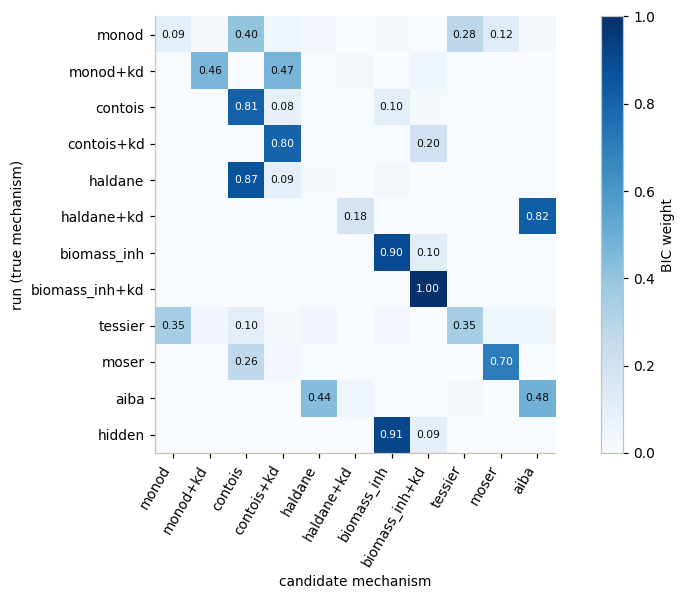

In [8]:
W = pd.DataFrame({name: r["sel"].weight for name, r in runs.items()}).T[list(MECHS)]
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(W.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(W.shape[1]))
ax.set_xticklabels(W.columns, rotation=60, ha="right")
ax.set_yticks(range(W.shape[0]))
ax.set_yticklabels(W.index)
ax.grid(False)
for i, j in zip(*np.nonzero(W.values >= 0.05)):
    ax.text(j, i, f"{W.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
            color="white" if W.values[i, j] > 0.6 else "#0b0b0b")
ax.set(xlabel="candidate mechanism", ylabel="run (true mechanism)")
fig.colorbar(im, fraction=0.03, label="BIC weight")
fig.tight_layout()

---
## Step 5 — symbolic regression on the learned rates

The library can only choose among the laws someone wrote down. Symbolic regression instead *proposes*
a law from the learned rate $\hat\mu(t)$ and the states $\hat X(t), \hat S(t)$ of the Neural ODE.

**A linear trick for rational laws.** Most rate laws are ratios of simple terms. Multiplying through by the
denominator makes them *linear in their coefficients*. For example, Haldane
$\mu = \mu_{max}S/(K_S + S + S^2/K_I)$ becomes

$$\mu S = \mu_{max}\,S \;-\; K_S\,\mu \;-\; \tfrac{1}{K_I}\,\mu S^2 .$$

So we regress $\mu S$ on a small dictionary of candidate terms

$$\mu S \;=\; \sum_k c_k\,\theta_k(X, S, \mu),\qquad
\theta \in \{\,S,\; SX,\; S^2,\; \mu,\; \mu X,\; \mu S^2,\; \mu S X\,\},$$

and ask for as few non-zero $c_k$ as possible (sparse regression, as in SINDy). Terms without μ build the
numerator and terms with μ build the denominator:

$$\mu \;=\; \frac{\sum_{\text{plain}} c_k\,\theta_k}{S - \sum_{\mu\text{-terms}} c_k\,\theta_k/\mu}.$$

| law | terms needed |
|---|---|
| Monod | $S$, $\mu$ |
| Contois | $S$, $\mu X$ |
| Haldane | $S$, $\mu$, $\mu S^2$ |
| biomass inhibition | $S$, $SX$, $\mu$ |
| **hidden law** | $S$, $SX$, $\mu$, $\mu S^2$ |
| Tessier, Moser, Aiba | not exactly expressible (exponentials, powers), only approximated |

**Sparsity.** With only 7 terms there are just 127 subsets, so we try every subset of up to 4 terms
(best-subset regression). SINDy's thresholded least squares is a fast approximation of this search when
the dictionary is too large to enumerate.

**Fitting each law.** Every subset of terms defines a rational law $\mu = N/D$. Its coefficients are
fitted to the learned $\hat\mu$ by least squares, like the library laws in step 2. The linear form above is
only used to *write* the laws. Fitting it directly by linear least squares weights each point by $D^2$, so
the late part of a run, where the denominator is large, dominates. On the Case 2 conversion rate that
picked physically impossible laws.

Two physical rules shape each fit:
* **Denominator terms are positive.** Every term of a rate law's denominator is positive, like $K_S$,
  $S^2/K_I$ or $K_c X$, so the fit keeps the denominator coefficients $\ge 0$. Unconstrained fits happily
  produce denominators such as $S - 1.2 - 0.06\,P$, which means product *activation*, and a rate that
  blows up.
* **The rate vanishes smoothly when the substrate runs out.** At least one denominator term must survive
  at $S = 0$, the same prior as the Neural ODE's own factor $S/(S+K)$. Otherwise laws such as
  $\mu = a + bX$ (where $S$ cancels) switch on abruptly at any $S > 0$.

For each number of terms we keep the **three** best valid laws that also have a numerator and a
non-negative rate along the run. Several laws fit $\hat\mu$ almost equally well, and the ranking at the rate
level is too uncertain to trust a single one. Without a numerator, models built only from μ-terms (for example $\mu S = a\mu + b\mu S^2$)
reduce to a relation among $S$ values alone and fit perfectly while meaning nothing.

**Deciding.** Along one run $X$ and $S$ change together, so several term sets can fit $\hat\mu$ about
equally well (the same confounding as in part 1). The candidates are therefore not trusted directly. Each
one becomes an ODE model, with and without $k_d$, and is refined against the data and scored with BIC,
exactly like the library mechanisms.

In [9]:
# A dictionary is the variable that multiplies mu on the left-hand side ("lhs") and the candidate terms.
# Each term is a function of the state v (a dict); terms named "mu..." are multiplied by mu, and their
# function gives the factor that multiplies mu. The same code serves Case 2 later, with other dictionaries.
SR_C1 = dict(lhs="S", vars=["X", "S"], terms={
    "S": lambda v: v["S"],
    "S*X": lambda v: v["S"] * v["X"],
    "S^2": lambda v: v["S"] ** 2,
    "mu": lambda v: v["S"] ** 0,
    "mu*X": lambda v: v["X"],
    "mu*S^2": lambda v: v["S"] ** 2,
    "mu*S*X": lambda v: v["S"] * v["X"],
})


def sr_parts(v, d, terms, coef):
    """Numerator and denominator of the rate law implied by  mu*lhs = sum_k c_k theta_k."""
    num = sum(c * d["terms"][k](v) for k, c in zip(terms, coef) if not k.startswith("mu")) + 0 * v[d["lhs"]]
    den = v[d["lhs"]] - sum(c * d["terms"][k](v) for k, c in zip(terms, coef) if k.startswith("mu"))
    return num, den


def sr_mu(v, d, terms, coef):
    num, den = sr_parts(v, d, terms, coef)
    return np.where(den > 1e-9, num / np.maximum(den, 1e-9), 0.0)      # 0 where the law is undefined


def fit_law(v, mu, d, terms):
    """Fit the law  mu = N/D  given by `terms` to the learned rate mu, like the library laws in step 2.
    N = sum of plain terms (free coefficients); D = lhs + sum of mu-terms (coefficients >= 0).
    Returns the coefficients in the  mu*lhs = sum_k c_k theta_k  convention and the relative error."""
    plain = [k for k in terms if not k.startswith("mu")]
    dens = [k for k in terms if k.startswith("mu")]
    N = np.column_stack([d["terms"][k](v) * np.ones_like(mu) for k in plain])
    Q = np.column_stack([d["terms"][k](v) * np.ones_like(mu) for k in dens] + [np.zeros_like(mu)])[:, :len(dens)]
    lhs = v[d["lhs"]]
    b0 = 0.1 * lhs.mean() / np.maximum(Q.mean(0), 1e-12)             # each denominator term ~10 % of lhs
    a0 = np.linalg.lstsq(N, mu * (lhs + Q @ b0), rcond=None)[0]

    def rate(p):
        den = lhs + Q @ p[len(plain):]
        return np.where(den > 1e-12, (N @ p[:len(plain)]) / np.maximum(den, 1e-12), 0.0)

    fit = least_squares(lambda p: rate(p) - mu, np.r_[a0, b0], x_scale="jac",
                        bounds=(np.r_[np.full(len(plain), -np.inf), np.zeros(len(dens))], np.inf))
    a, b = dict(zip(plain, fit.x[:len(plain)])), dict(zip(dens, fit.x[len(plain):]))
    coef = np.array([a[k] if k in a else -b[k] for k in terms])
    return coef, np.linalg.norm(rate(fit.x) - mu) / np.linalg.norm(mu)


def sr_candidates(v, mu, d, max_terms=4, per_size=1):
    """The `per_size` best valid laws of each size, over all subsets of the dictionary d:
    list of (term names, coefficients, relative error of mu), sorted by size and error."""
    found = []
    for size in range(1, max_terms + 1):
        valid = []
        for terms in itertools.combinations(d["terms"], size):
            terms = list(terms)
            if all(k.startswith("mu") for k in terms):
                continue                                             # no numerator: not a rate law
            coef, err = fit_law(v, mu, d, terms)
            dens = [(c, k) for c, k in zip(coef, terms) if k.startswith("mu")]
            if any(-c * np.mean(d["terms"][k](v)) < 1e-6 * np.mean(v[d["lhs"]]) for c, k in dens):
                continue                                             # a denominator term is switched off
            _, den0 = sr_parts({**v, d["lhs"]: 0 * v[d["lhs"]]}, d, terms, coef)   # substrate used up
            if np.any(den0 <= 0) or np.any(sr_mu(v, d, terms, coef) < 0):
                continue                                             # not a valid rate law
            valid.append((terms, coef, err))
        found += sorted(valid, key=lambda c: c[2])[:per_size]
    return found


def sr_formula(d, terms, coef, digits=3):
    """Pretty rate law, normalised so the constant in the denominator (if any) is 1."""
    sym = {name: sp.Symbol(name, positive=True) for name in d["vars"]}
    num, den = sr_parts(sym, d, terms, [sp.Float(c, digits) for c in coef])
    const = den.subs({s_: 0 for s_ in sym.values()})
    if const != 0:
        num, den = sp.expand(num / const), sp.expand(den / const)
    return sp.N(num, digits) / sp.N(den, digits)


Xs, Ss = sp.symbols("X S", positive=True)

Candidates proposed for four representative runs. Each row is the best valid law with that many terms,
and "rel. error" is its error against the learned rate. All candidates (three per size) of every run are
refined below.

Some fits run off to very large coefficients, such as the 3-term law of the biomass-inhibition run. Both
numerator and denominator grow together, so that is a *limit* in which the $S$ term of the denominator drops
out; here the law is effectively $\mu \approx (0.231\,S - 0.0070\,S^2)/X$.

In [10]:
rows = []
for name, r in runs.items():
    r["sr"] = sr_candidates({"X": r["dense"]["X"], "S": r["dense"]["S"]}, r["dense"]["mu"], SR_C1, per_size=3)
for name in ["monod", "biomass_inh", "haldane", "hidden"]:
    for terms, coef, err in [c for i, c in enumerate(runs[name]["sr"])
                             if i == 0 or len(c[0]) != len(runs[name]["sr"][i - 1][0])]:   # best of each size
        rows.append({"run": name, "terms": len(terms), "rate law": str(sr_formula(SR_C1, terms, coef)),
                     "rel. error": round(err, 3)})
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows).set_index(["run", "terms"])

rate law  \
run         terms                                                         
monod       2                                   0.177*S/(0.327*S + 1.0)   
            3                 (-0.000151*S*X + 0.182*S)/(0.335*S + 1.0)   
            4       0.182*S/(0.000281*S*X + 0.335*S + 0.000898*X + 1.0)   
biomass_inh 2                                      0.536*S/(S + 4.37*X)   
            3               (-9.69e+5*S**2 + 3.19e+7*S)/(S + 1.38e+8*X)   
            4      (-0.00362*S**2 - 0.0248*S*X + 0.556*S)/(S + 0.194*X)   
haldane     2                                      0.193*S/(S + 3.39*X)   
            3                        0.185*S/(0.0684*S*X + S + 0.487*X)   
            4          0.202*S/(0.00334*S**2 + 0.0595*S*X + S + 0.98*X)   
hidden      2                                     0.296*S/(S + 0.468*X)   
            3                    (-0.0074*S*X + 0.308*S)/(S + 0.0739*X)   
            4         (-0.0146*S*X + 0.55*S)/(0.0301*S**2 + S + 0.23*X)   

                   rel. error  
run         terms              
monod       2           0.002  
            3           0.000  
            4           0.000  
biomass_inh 2           0.350  
            3           0.217  
            4           0.019  
haldane     2           0.025  
            3           0.002  
            4           0.001  
hidden      2           0.079  
            3           0.063  
            4           0.005

Every candidate (up to 9 laws per run, each with and without $k_d$, so up to 18 models) is now refined
against the data like a library mechanism. Its parameters are the coefficients $c_k$ (kept to their sign,
within 0.1×–10× of the regression value), $Y_{XS}$, and optionally $k_d$. They are then compared by BIC with
the refined library mechanisms.

Several candidates are *the same law* as a library mechanism, written as terms. For example, $\{S,\ \mu X\}$
is exactly Contois and $\{S,\ \mu\}$ is exactly Monod. Such a candidate ties with its library twin
(ΔBIC ≈ 0) and the two share the BIC weight, so the weights below are lower than in the library-only table.

In [11]:
def sr_models(r):
    """Library-style entries for the SR candidates of one run: name -> (terms, start, lower, upper, death)."""
    models = {}
    for terms, coef, _ in r["sr"]:
        lo, hi = np.minimum(0.1 * coef, 10 * coef), np.maximum(0.1 * coef, 10 * coef)
        for death in (False, True):
            start = np.r_[coef, [r["dense"]["kd"]] if death else [], r["dense"]["Yxs"]]
            lower = np.r_[lo, [0.0005] if death else [], 0.03]
            upper = np.r_[hi, [0.5] if death else [], 3.0]
            models[f"SR: {' + '.join(terms)}{' +kd' if death else ''}"] = (terms, start, lower, upper, death)
    return models


def simulate_sr(model, theta, t, x0):
    terms, _, _, _, death = model
    k = len(terms)
    p = {"Yxs": theta[-1], "kd": theta[k] if death else 0.0}
    return simulate_mech(lambda X, S, _p: sr_mu({"X": X, "S": S}, SR_C1, terms, theta[:k]), p, t, x0)


for name, r in runs.items():
    t0 = time.time()
    models = sr_models(r)
    sr_sel = identify(list(models), starts=lambda m: {"SR": models[m][1]},
                      simulate=lambda m, th, t, x0: simulate_sr(models[m], th, t, x0),
                      bounds=lambda m: models[m][2:4], x0=r["x0"],
                      t_obs=t_obs, Y_obs=r["Y"], sigma=r["sigma"])
    r["models"] = models
    r["all"] = add_bic(pd.concat([r["sel"], sr_sel]), N_DATA)
    print(f"{name:15s} {len(models)} SR models refined in {time.time() - t0:.0f} s")

rows = []
for name, r in runs.items():
    df = r["all"]
    lib = df.loc[list(MECHS)]
    srs = df.drop(index=list(MECHS))
    best, best_sr = df.BIC.idxmin(), srs.BIC.idxmin()
    rows.append({"run": name, "overall best": best, "weight": round(df.weight[best], 2),
                 "best library χ²": round(lib.chi2.min(), 1), "best SR χ²": round(srs.chi2[best_sr], 1),
                 "ΔBIC (SR − library)": round(srs.BIC.min() - lib.BIC.min(), 1),
                 "best SR law": str(sr_formula(SR_C1, r["models"][best_sr][0],
                                               srs.theta[best_sr][:len(r["models"][best_sr][0])]))})
pd.DataFrame(rows).set_index("run")

monod           18 SR models refined in 10 s


monod+kd        18 SR models refined in 16 s


contois         18 SR models refined in 7 s


contois+kd      18 SR models refined in 8 s


haldane         18 SR models refined in 5 s


...

tessier         18 SR models refined in 15 s


moser           18 SR models refined in 9 s


aiba            18 SR models refined in 25 s


hidden          18 SR models refined in 11 s


,overall best,weight,best library χ²,best SR χ²,ΔBIC (SR − library),best SR law
run,,,,,,
monod,contois,0.25,68.2,70.4,0.0,0.496*S/(S + 0.147*X)
monod+kd,SR: S + mu*X +kd,0.23,53.9,53.9,-0.0,0.465*S/(S + 0.0995*X)
contois,SR: S + mu*X,0.39,85.0,85.7,-0.0,0.47*S/(S + 0.905*X)
contois+kd,contois+kd,0.35,107.4,109.2,0.0,0.502*S/(S + 0.956*X)
haldane,contois,0.38,83.3,83.5,0.0,0.187*S/(S + 4.03*X)
haldane+kd,aiba,0.82,68.4,108.9,39.0,(-0.0283*S*X + 0.147*S)/(S + 0.207*X)
biomass_inh,biomass_inh,0.69,62.9,63.1,4.5,(-0.0285*S*X + 0.562*S)/(0.00599*S**2 + S + 0.104*X)
biomass_inh+kd,biomass_inh+kd,0.30,60.0,60.0,0.0,(-0.0326*S*X + 0.644*S)/(1.28*S + 1.0)
tessier,tessier,0.22,80.6,81.0,0.0,0.156*S/(0.21*S + 1.0)


## The hidden run, up close

Data, the Neural ODE, the best library mechanism and the best symbolic-regression law.

,rate law,χ²
true (hidden),-0.6*S*(0.0333*X - 1.0)/(0.05*S**2 + 1.0*S + 1.0),
found (SR: S + S*X + mu + mu*S^2),(-0.0111*S*X + 0.339*S)/(0.0313*S**2 + 0.509*S + 1.0),73.4


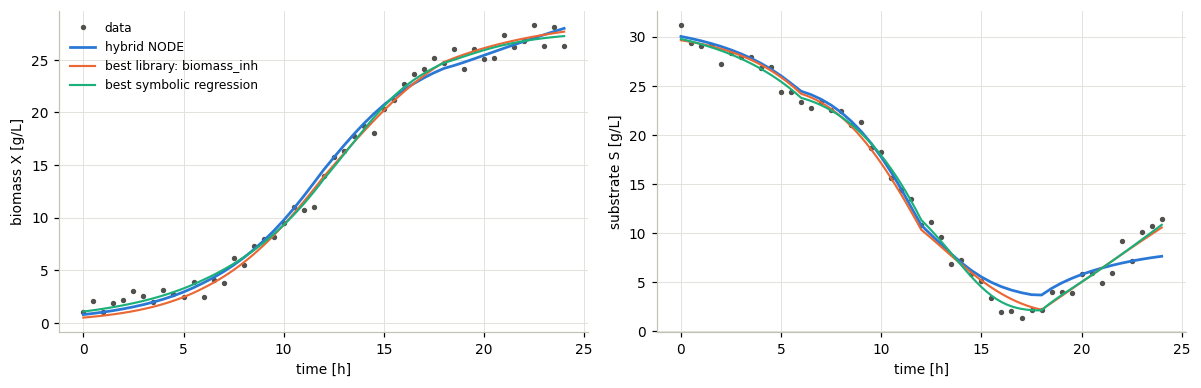

In [12]:
r = runs["hidden"]
df = r["all"]
best_lib = df.loc[list(MECHS)].BIC.idxmin()
best_sr = df.drop(index=list(MECHS)).BIC.idxmin()
lib_fit = simulate(best_lib, df.theta[best_lib], T_DENSE, df.x0[best_lib])
sr_fit = simulate_sr(r["models"][best_sr], df.theta[best_sr], T_DENSE, df.x0[best_sr])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for j, (ax, lab) in enumerate(zip(axes, ["biomass X [g/L]", "substrate S [g/L]"])):
    ax.plot(t_obs, r["Y"][:, j], "o", color=C_DATA, ms=2.5, label="data")
    ax.plot(T_DENSE, [r["dense"]["X"], r["dense"]["S"]][j], color=C_NODE, label="hybrid NODE")
    ax.plot(T_DENSE, lib_fit[:, j], color=C_MECH, lw=1.4, label=f"best library: {best_lib}")
    ax.plot(T_DENSE, sr_fit[:, j], color=C_SR, lw=1.4, label="best symbolic regression")
    ax.set(xlabel="time [h]", ylabel=lab)
axes[0].legend()
fig.tight_layout()

k = len(r["models"][best_sr][0])
true_law = HIDDEN_P["mumax"] * Ss / (HIDDEN_P["Ks"] + Ss + Ss ** 2 / HIDDEN_P["KI"]) * (1 - Xs / HIDDEN_P["Xmax"])
pd.DataFrame({"rate law": [str(sp.N(sp.factor(true_law), 3)),
                           str(sr_formula(SR_C1, r["models"][best_sr][0], df.theta[best_sr][:k]))],
              "χ²": ["", round(df.chi2[best_sr], 1)]},
             index=["true (hidden)", f"found ({best_sr})"])

**Reading the law that was found.** Its terms $\{S,\ SX,\ \mu,\ \mu S^2\}$ are exactly those of the true
law. Rewritten in the usual form, it is

$$\mu \approx 0.666\,\frac{S\,(1 - X/30.5)}{1.96 + S + S^2/16.3},$$

against the true $\mu = 0.6\,S\,(1 - X/30)\,/\,(1 + S + S^2/20)$. Symbolic regression recovered the whole
structure: the logistic factor ($X_{max} \approx 30.5$ vs 30), the substrate-inhibition term ($K_I \approx 16$
vs 20) and the saturation constant ($K_S \approx 2.0$ vs 1.0, the least identifiable one, as in part 1).


---
## Case 2 — xylitol: symbolic regression on two rates

The same two virtual fermentations as in part 1: a BC18-like run generated with **M31** (the paper's
Table 7 parameters) and a BC15-like run generated with **M28**, each with 13 offline samples and 5 % noise.

* **Step 1:** the hybrid Neural ODE of part 1, $[\mu_1, \mu_2] = \mathrm{NN}_\phi(S_1, S_2, P)$ with trainable
  $Y_{XS_1}$, $Y_{PS_2}$ and $k_d$. Its initial state starts from the *first* sample: with sparse sampling,
  the first three samples span 8 h of growth.
* **Steps 2–4:** the 11 library mechanisms M21–M31 are matched, refined and ranked as in part 1.
* **Step 5:** there are now two rates to explain, so each gets its own dictionary:

$$\mu_1 S_1 = \sum_k c_k\,\theta_k,\quad \theta \in \{S_1,\ \mu_1,\ \mu_1 S_2^2,\ \mu_1 P,\ \mu_1 S_1 P\},$$

$$\mu_2 S_2 = \sum_k c_k\,\theta_k,\quad \theta \in \{S_2,\ \mu_2,\ \mu_2 S_2^2,\ \mu_2 P,\ \mu_2 S_2 P,\ \mu_2 S_2^2 P\}.$$

The μ1 dictionary covers every growth-side term of the library: Monod, cross-inhibition by xylose
($K_{SI_1}$) and product inhibition ($K_{PI_1}$). The μ2 dictionary covers every conversion law; M31 needs
all six terms. For example, M28's conversion law
$\mu_2 = \mu_{max,2}\,S_2 / \big((K_P + S_2)(1 + P/K_{PI_2})\big)$ becomes

$$\mu_2 S_2 = \mu_{max,2}\,S_2 - K_P\,\mu_2 - \tfrac{K_P}{K_{PI_2}}\,\mu_2 P - \tfrac{1}{K_{PI_2}}\,\mu_2 S_2 P .$$

The best valid law of each size for μ1 (up to 3 terms) and μ2 (up to 5 terms) are combined into full ODE
models, with and without $k_d$. They are refined against the data and ranked by BIC together with the
library.

In [13]:
from kinetic_models.base_models import get_model
from kinetic_models.feed_fun import get_feed_cached
from datagen.feed_profiles import make_exter_df
from datagen.param_ranges_v2 import get_param_names as names_c2, get_param_bounds as bounds_c2

MECHS_C2 = list(range(21, 32))
NOISE_C2 = 0.05
IC_C2 = [1.0, 20.0, 0.0, 0.0, 0.28]                   # X0, S1_0, S2_0, P0 [g/L], V0 [L]
RUNS_C2 = {
    "BC18-like": dict(mech=31, params=[0.32, 5.54, 0.62, 1.24, 0.17, 40.0, 0.018, 23.4, 8.52],
                      feed=dict(t_start=20.0, F_initial=2.0, F_step=2.5, t_step_offset=60.0, has_step=True,
                                S1_feed=85.0, S2_feed=300.0, t_total=140.0),
                      t=[0, 4, 8, 12, 16, 22, 30, 45, 60, 80, 100, 120, 140]),
    "BC15-like": dict(mech=28, params=[0.30, 4.00, 0.70, 1.30, 0.10, 60.0, 10.0],
                      feed=dict(t_start=25.0, F_initial=1.5, F_step=3.0, t_step_offset=35.0, has_step=True,
                                S1_feed=108.8, S2_feed=334.0, t_total=100.0),
                      t=[0, 3, 6, 9, 12, 16, 21, 28, 40, 55, 70, 85, 100]),
}
for i, r in enumerate(RUNS_C2.values()):                # the same data as in part 1
    r["exter"] = make_exter_df(r["feed"], idx=i)          # kintrace feed description
    r["S1f"], r["S2f"], r["feed_fn"] = get_feed_cached(r["exter"])
    r["t"], r["V0"] = np.array(r["t"], dtype=float), IC_C2[4]
    truth = scipy_odeint(get_model(f"model{r['mech']}"), IC_C2, r["t"], args=(np.array(r["params"]), r["exter"]),
                         rtol=1e-8, atol=1e-10)
    r["Y"] = add_gaussian_noise(truth[:, :4], NOISE_C2, clip_zero=True, seed=i)   # observe X, S1, S2, P
    r["sigma"] = NOISE_C2 * (r["Y"].max(0) - r["Y"].min(0))


def run_ode(fun, args, x0, t, V0):
    """Integrate a 5-state xylitol model; returns [X, S1, S2, P] or None if it fails or blows up."""
    try:
        with fortran_quiet():
            y = scipy_odeint(fun, [*x0, V0], t, args=args, rtol=1e-6, atol=1e-8, mxstep=5000)
    except Exception:
        return None
    return y[:, :4] if np.all(np.isfinite(y)) and np.abs(y).max() < 1e6 else None


def rhs_c2(y, t, mu1_fn, mu2_fn, p, run):
    """Paper Eq. 8 for any rate laws mu1_fn(v), mu2_fn(v) of the state v = {S1, S2, P}."""
    X, S1, S2, P = np.maximum(y[:4], 0.0)
    F = run["feed_fn"](t) / 1000.0                         # mL/h -> L/h
    D = F / y[4]
    v = {"S1": S1, "S2": S2, "P": P}
    mu1, mu2 = mu1_fn(v), mu2_fn(v)
    return [(mu1 - p["kd"] - D) * X, -mu1 * X / p["Yxs1"] + D * (run["S1f"] - S1),
            -mu2 * X / p["Yps2"] + D * (run["S2f"] - S2), mu2 * X - D * P, F]


class HybridXylitol(HybridODE):
    step = 1.0

    def __init__(self, Y_obs, run):
        super().__init__(Y_obs, run["V0"], n_start=1)
        self.run, self.Sf = run, torch.tensor([run["S1f"], run["S2f"]])
        self.net = mlp(3, 2)
        self.log_Y = nn.Parameter(torch.log(torch.tensor([0.5, 1.0])))     # Y_XS1, Y_PS2
        self.log_kd = nn.Parameter(torch.tensor(np.log(0.01)))
        self.K = torch.tensor([0.25, 0.1]) * self.scale[1:3]

    def rates(self, S1, S2, P):
        S = torch.stack([S1, S2], -1).clamp(min=0)
        g = nn.functional.softplus(self.net(torch.stack([S1, S2, P], -1) / self.scale[1:]))
        mu = g * S / (S + self.K)
        return mu[..., 0], mu[..., 1]

    def forward(self, t, y):
        X, S1, S2, P, V = y.unbind(-1)
        F = self.run["feed_fn"](float(t)) / 1000.0
        D = F / V
        mu1, mu2 = self.rates(S1, S2, P)
        Yxs1, Yps2 = torch.exp(self.log_Y)
        return torch.stack([(mu1 - torch.exp(self.log_kd) - D) * X, -mu1 * X / Yxs1 + D * (self.Sf[0] - S1),
                            -mu2 * X / Yps2 + D * (self.Sf[1] - S2), mu2 * X - D * P, torch.full_like(V, F)])


for name, r in RUNS_C2.items():
    t0 = time.time()
    torch.manual_seed(0)
    node = HybridXylitol(r["Y"], r)
    loss = train_node(node, r["t"], r["Y"], n_iter=200, lr=1e-2)
    r["t_dense"] = np.linspace(0, r["t"][-1], 141)
    with torch.no_grad():
        yd = node.simulate(r["t_dense"])
        mu1, mu2 = node.rates(yd[:, 1], yd[:, 2], yd[:, 3])
    yd = yd.numpy()
    r["v"] = {"S1": np.clip(yd[:, 1], 0, None), "S2": np.clip(yd[:, 2], 0, None), "P": np.clip(yd[:, 3], 0, None)}
    r["dense"] = dict(mu1=mu1.numpy(), mu2=mu2.numpy(), kd=torch.exp(node.log_kd).item(),
                      yields=torch.exp(node.log_Y).tolist())
    r["x0"] = np.clip(yd[0, :4], 0, None)
    print(f"{name}: NODE loss {loss:.1e}  Y_XS1 {r['dense']['yields'][0]:.2f}  Y_PS2 {r['dense']['yields'][1]:.2f}  "
          f"k_d {r['dense']['kd']:.4f}  [{time.time() - t0:.0f} s]")

BC18-like: NODE loss 1.3e-03  Y_XS1 0.55  Y_PS2 1.28  k_d 0.0148  [63 s]


BC15-like: NODE loss 2.0e-03  Y_XS1 0.78  Y_PS2 1.25  k_d 0.0050  [42 s]


**Library selection (steps 2–4), as in part 1.** Each mechanism is started from the rate law matched to the
learned μ1, μ1 − $k_d$ and μ2, and from the centre of its ranges, then refined with kintrace's ODE.

In [14]:
def library_rates(p, S1, S2, P):
    """mu1, mu2 and kd of models 21-31 (base_models.py), for arrays or sympy symbols."""
    mu1 = p["mumax1"] * S1 / (p["KS1"] + S1 + (S2 ** 2 / p["KSI1"] if "KSI1" in p else 0))
    mu1 = mu1 / (1 + P / p["KPI1"]) if "KPI1" in p else mu1
    mu2 = p["mumax2"] * S2 / (p["KP"] + S2 + (S2 ** 2 / p["KSI2"] if "KSI2" in p else 0))
    mu2 = mu2 / (1 + P / p["KPI2"]) if "KPI2" in p else mu2
    return mu1, mu2, p.get("kd", 0.0)


def bounds_wide_c2(m):
    lo, hi = bounds_c2(m)
    return np.array(lo) * 0.1, np.array(hi) * 5


def match_c2(m, r):
    names = names_c2(m)
    kin = [i for i, n in enumerate(names) if n not in ("YXS1", "YPS2")]
    lb, ub = bounds_wide_c2(m)
    lo, hi = bounds_c2(m)
    d, v = r["dense"], r["v"]
    s1, s2 = d["mu1"].max() + 1e-9, d["mu2"].max() + 1e-9

    def residuals(theta_kin):
        mu1, mu2, kd = library_rates(dict(zip([names[i] for i in kin], theta_kin)), v["S1"], v["S2"], v["P"])
        return np.concatenate([(mu1 - d["mu1"]) / s1, (mu1 - kd - d["mu1"] + d["kd"]) / s1, (mu2 - d["mu2"]) / s2])

    fit = least_squares(residuals, 0.5 * (np.array(lo) + np.array(hi))[kin], bounds=(lb[kin], ub[kin]),
                        x_scale=(ub - lb)[kin])
    theta = np.empty(len(names))
    theta[kin] = fit.x
    theta[names.index("YXS1")], theta[names.index("YPS2")] = d["yields"]
    return np.clip(theta, lb, ub)


for name, r in RUNS_C2.items():
    t0 = time.time()
    r["sel"] = identify(MECHS_C2,
                        starts=lambda m: {"NODE": match_c2(m, r), "centre": 0.5 * np.sum(bounds_c2(m), 0)},
                        simulate=lambda m, th, t, x0: run_ode(get_model(f"model{m}"), (th, r["exter"]), x0, t, r["V0"]),
                        bounds=bounds_wide_c2, x0=r["x0"], t_obs=r["t"], Y_obs=r["Y"], sigma=r["sigma"])
    print(f"{name}: 11 library mechanisms refined in {time.time() - t0:.0f} s")

BC18-like: 11 library mechanisms refined in 70 s


BC15-like: 11 library mechanisms refined in 50 s


**Symbolic regression (step 5).** The best valid laws found for each rate:

In [15]:
SR_MU1 = dict(lhs="S1", vars=["S1", "S2", "P"], terms={
    "S1": lambda v: v["S1"],
    "mu1": lambda v: v["S1"] ** 0,
    "mu1*S2^2": lambda v: v["S2"] ** 2,
    "mu1*P": lambda v: v["P"],
    "mu1*S1*P": lambda v: v["S1"] * v["P"],
})
SR_MU2 = dict(lhs="S2", vars=["S2", "P"], terms={
    "S2": lambda v: v["S2"],
    "mu2": lambda v: v["S2"] ** 0,
    "mu2*S2^2": lambda v: v["S2"] ** 2,
    "mu2*P": lambda v: v["P"],
    "mu2*S2*P": lambda v: v["S2"] * v["P"],
    "mu2*S2^2*P": lambda v: v["S2"] ** 2 * v["P"],
})

rows = []
for name, r in RUNS_C2.items():
    r["sr1"] = sr_candidates(r["v"], r["dense"]["mu1"], SR_MU1, max_terms=3)
    r["sr2"] = sr_candidates(r["v"], r["dense"]["mu2"], SR_MU2, max_terms=5)
    for rate, d, cands in [("μ1", SR_MU1, r["sr1"]), ("μ2", SR_MU2, r["sr2"])]:
        for terms, coef, err in cands:
            rows.append({"run": name, "rate": rate, "terms": len(terms), "law": str(sr_formula(d, terms, coef)),
                         "rel. error": round(err, 3)})
pd.DataFrame(rows).set_index(["run", "rate", "terms"])

law  \
run       rate terms                                                                         
BC18-like μ1   2                                                0.0946*S1/(0.231*S1 + 1.0)   
               3                                      0.179*S1/(0.0147*P + 0.493*S1 + 1.0)   
          μ2   2                                                  0.608*S2/(4.63*S2 + 1.0)   
               3                              0.0746*S2/(0.00616*P*S2 + 0.000937*S2 + 1.0)   
               4                   0.0772*S2/(0.00618*P*S2 + 0.00358*P + 6.57e-7*S2 + 1.0)   
BC15-like μ1   2                                                 0.0862*S1/(0.23*S1 + 1.0)   
               3                                     0.094*S1/(0.00212*P + 0.257*S1 + 1.0)   
          μ2   2                                                  0.205*S2/(2.21*S2 + 1.0)   
               3                                 0.0734*S2/(0.00214*P*S2 + 0.581*S2 + 1.0)   
               4                     0.0715*S2/(0.00192*P*S2 + 0.00854*P + 0.533*S2 + 1.0)   
               5      0.0668*S2/(0.00118*P*S2 + 0.0127*P + 0.00361*S2**2 + 0.461*S2 + 1.0)   

                      rel. error  
run       rate terms              
BC18-like μ1   2           0.121  
               3           0.061  
          μ2   2           0.291  
               3           0.092  
               4           0.091  
BC15-like μ1   2           0.026  
               3           0.017  
          μ2   2           0.067  
               3           0.015  
               4           0.006  
               5           0.004

Every combination of a μ1 law and a μ2 law, with and without $k_d$, is refined against the data and ranked
by BIC together with the 11 library mechanisms.

In [16]:
def sr_models_c2(r):
    """Full-model candidates: name -> (mu1 terms, mu2 terms, start, lower, upper, death)."""
    models = {}
    for (t1, c1, _), (t2, c2, _) in itertools.product(r["sr1"], r["sr2"]):
        coef = np.r_[c1, c2]
        lo, hi = np.minimum(0.1 * coef, 10 * coef), np.maximum(0.1 * coef, 10 * coef)
        for death in (False, True):
            start = np.r_[coef, [r["dense"]["kd"]] if death else [], r["dense"]["yields"]]
            lower = np.r_[lo, [0.0005] if death else [], 0.03, 0.03]
            upper = np.r_[hi, [0.5] if death else [], 5.0, 5.0]
            models[f"SR: μ1[{' + '.join(t1)}] μ2[{' + '.join(t2)}]{' +kd' if death else ''}"] = \
                (t1, t2, start, lower, upper, death)
    return models


def simulate_sr_c2(model, theta, t, x0, run):
    t1, t2, _, _, _, death = model
    n1, n2 = len(t1), len(t2)
    p = {"kd": theta[n1 + n2] if death else 0.0, "Yxs1": theta[-2], "Yps2": theta[-1]}
    mu1_fn = lambda v: sr_mu(v, SR_MU1, t1, theta[:n1])
    mu2_fn = lambda v: sr_mu(v, SR_MU2, t2, theta[n1:n1 + n2])
    return run_ode(rhs_c2, (mu1_fn, mu2_fn, p, run), x0, t, run["V0"])


for name, r in RUNS_C2.items():
    t0 = time.time()
    r["models"] = models = sr_models_c2(r)
    sr_sel = identify(list(models), starts=lambda m: {"SR": models[m][2]},
                      simulate=lambda m, th, t, x0: simulate_sr_c2(models[m], th, t, x0, r),
                      bounds=lambda m: models[m][3:5], x0=r["x0"], t_obs=r["t"], Y_obs=r["Y"], sigma=r["sigma"])
    r["all"] = add_bic(pd.concat([r["sel"], sr_sel]), r["Y"].size)
    print(f"{name}: {len(models)} symbolic-regression models refined in {time.time() - t0:.0f} s")

S1s, S2s, Ps = sp.symbols("S1 S2 P", positive=True)
rows = []
for name, r in RUNS_C2.items():
    df = r["all"]
    lib, srs = df.loc[MECHS_C2], df.drop(index=MECHS_C2)
    best_lib, best_sr = lib.BIC.idxmin(), srs.BIC.idxmin()
    t1, t2 = r["models"][best_sr][:2]
    theta = srs.theta[best_sr]
    _, true_mu2, _ = library_rates(dict(zip(names_c2(r["mech"]), r["params"])), S1s, S2s, Ps)
    rows.append({"run": name, "true": f"M{r['mech']}", "overall best": df.BIC.idxmin(),
                 "weight": round(df.weight.max(), 2),
                 "best library (χ²)": f"M{best_lib} ({lib.chi2[best_lib]:.1f})",
                 "best SR χ²": round(srs.chi2[best_sr], 1),
                 "ΔBIC (SR − library)": round(srs.BIC[best_sr] - lib.BIC[best_lib], 1),
                 "SR μ1": str(sr_formula(SR_MU1, t1, theta[:len(t1)])),
                 "SR μ2": str(sr_formula(SR_MU2, t2, theta[len(t1):len(t1) + len(t2)])),
                 "true μ2": str(sp.N(true_mu2, 3))})
pd.DataFrame(rows).set_index("run").T

BC18-like: 12 symbolic-regression models refined in 33 s


BC15-like: 16 symbolic-regression models refined in 77 s


run,BC18-like,BC15-like
true,M31,M28
overall best,SR: μ1[S1 + mu1] μ2[S2 + mu2 + mu2*S2*P] +kd,28
weight,0.41,0.51
best library (χ²),M31 (27.9),M28 (21.1)
best SR χ²,29.6,22.6
ΔBIC (SR − library),-2.2,1.5
SR μ1,0.183*S1/(0.458*S1 + 1.0),0.228*S1/(0.61*S1 + 1.0)
SR μ2,0.057*S2/(0.00451*P*S2 + 0.000869*S2 + 1.0),0.0237*S2/(0.00181*P*S2 + 0.0581*S2 + 1.0)
true μ2,5.54*S2/((0.117*P + 1.0)*(0.0427*S2**2 + S2 + 40.0)),4.0*S2/((0.1*P + 1.0)*(S2 + 60.0))


Learned and found rates compared with the true ones. The found rates are evaluated along their own refined
trajectories.

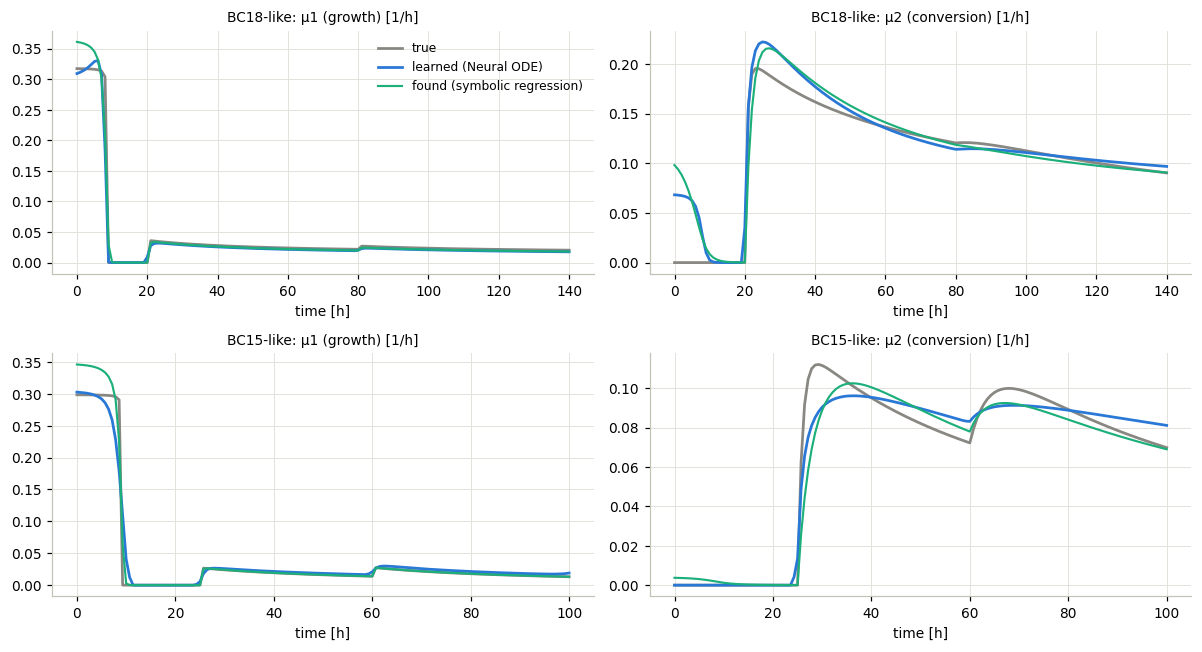

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for row, (name, r) in zip(axes, RUNS_C2.items()):
    df = r["all"]
    best_sr = df.drop(index=MECHS_C2).BIC.idxmin()
    t1, t2 = r["models"][best_sr][:2]
    theta, x0 = df.theta[best_sr], df.x0[best_sr]
    truth = scipy_odeint(get_model(f"model{r['mech']}"), IC_C2, r["t_dense"], args=(np.array(r["params"]), r["exter"]))
    mu1_t, mu2_t, _ = library_rates(dict(zip(names_c2(r["mech"]), r["params"])), truth[:, 1], truth[:, 2], truth[:, 3])
    sr_traj = simulate_sr_c2(r["models"][best_sr], theta, r["t_dense"], x0, r)
    v_sr = {"S1": np.clip(sr_traj[:, 1], 0, None), "S2": np.clip(sr_traj[:, 2], 0, None), "P": np.clip(sr_traj[:, 3], 0, None)}
    found = [sr_mu(v_sr, SR_MU1, t1, theta[:len(t1)]), sr_mu(v_sr, SR_MU2, t2, theta[len(t1):len(t1) + len(t2)])]
    for ax, true_mu, learned, fnd, lab in zip(row, [mu1_t, mu2_t], [r["dense"]["mu1"], r["dense"]["mu2"]], found,
                                             ["μ1 (growth) [1/h]", "μ2 (conversion) [1/h]"]):
        ax.plot(r["t_dense"], true_mu, color=C_TRUE, label="true")
        ax.plot(r["t_dense"], learned, color=C_NODE, label="learned (Neural ODE)")
        ax.plot(r["t_dense"], fnd, color=C_SR, lw=1.4, label="found (symbolic regression)")
        ax.set(title=f"{name}: {lab}", xlabel="time [h]")
axes[0, 0].legend()
fig.tight_layout()

---
## Takeaways

**Library selection with 11 mechanisms**
* **Accuracy.** The true mechanism is ranked first in 7 of 11 runs and shortlisted ($w > 0.1$) in 9 of 11.
  With 4 mechanisms (part 1) all four were ranked first, so a larger library means more near-ties and
  lower weights.
* **The misses are genuine ambiguities.** Monod, Contois, Tessier and Moser differ mainly at low $S$,
  which the fed phase visits below the noise level. On the Haldane run, $X$ and $S$ rise together, so a
  falling μ can be blamed on either one, and Contois fits as well. Haldane+$k_d$ and Aiba are two forms
  of substrate inhibition.
* **Death is detected.** Every death run has its +$k_d$ mechanism selected or shortlisted, and no
  death-free run selects one. The Neural ODE's learned $k_d$ is about 0.03 h⁻¹ for three of the four
  death runs (true 0.04; 0.012 for Haldane+$k_d$), and 0.006–0.016 for the death-free runs.

**Symbolic regression, Case 1**
* **No false discoveries.** On all 11 library runs, the best symbolic-regression law ties with or loses to
  the best library mechanism (ΔBIC from −0.0 to +39). Most ties are rediscoveries of a library law in term
  form: Contois $\{S, \mu X\}$ on the Monod, Monod+$k_d$, Contois, Contois+$k_d$ and Haldane runs, biomass
  inhibition $\{S, SX, \mu\}$ on the biomass-inhibition+$k_d$ run, and Monod $\{S, \mu\}$ on the Tessier run. On the Aiba run a new law ties (ΔBIC +0.1), because the data barely
  constrain the shape there.
* **It finds the missing law.** On the hidden run, it beats the best library mechanism by ΔBIC ≈ 28
  (weight 0.59) and recovers the true law's structure term for term. The χ² test alone would *not* have
  flagged this run: the best library mechanism reaches χ² = 106 for 98 data points, inside the noise band.
* **Readable laws on library runs too.** The biomass-inhibition run gives a logistic law with
  $X_{max} \approx 19.7$ (true 20). Tessier, Moser and Aiba can only be approximated with this dictionary.

**Symbolic regression, Case 2**
* **It recovers the key ingredients in both runs:** Monod growth, death where the run has it (BC18-like),
  and product inhibition of conversion, as a $P\,S_2$ term in the denominator of μ2. In BC15-like that
  term's coefficient is 0.0018, against 0.0017 in the true law.
* **The found laws tie with the true library mechanism.** On BC18-like the best found law is
  $\mu_2 \approx 0.057\,S_2/(1 + 0.0009\,S_2 + 0.0045\,P S_2)$ with Monod μ1 and death. It has one parameter
  fewer than M31 and ranks first (ΔBIC −2.2; weight 0.41 vs 0.13 for M31). On BC15-like, M28 stays first and
  the best found law is 1.5 BIC units behind. Differences this small are not evidence either way: with 13
  samples per species, compact forms and the textbook laws describe the data equally well.

**Caveats**
* **The confounding carries over.** Symbolic regression reads the learned rates along one trajectory, so
  it inherits the X/S confounding. On the Haldane run it proposes a Contois-type law, like the library.
* **The dictionary limits what can be found.** Only rational laws built from the 7 terms can be
  expressed; exponentials and non-integer powers are out of reach.
* **The Neural ODE's χ² is only a rough reference.** A few hundred Adam steps leave it above a refined
  mechanism in several runs.

**Next steps**
1. **Break the confounding.** Fit several runs with different feeds or initial substrate jointly, so that
   $X$ and $S$ vary independently. This would help both library selection and symbolic regression most.
2. **Reach non-rational laws.** Add exponential terms to the dictionary, or use genetic-programming
   symbolic regression (for example PySR).
3. **Close the loop.** Add accepted symbolic-regression laws to the library for later runs.